In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import euclidean
from sklearn.metrics import confusion_matrix

In [12]:
# ==========================================
# LOAD DATA
# ==========================================

file_path = "../Data/stresstest1_train/training_data4.csv"

df = pd.read_csv(file_path, sep=';')

print(df.head())

print("\nColumns:")
print(df.columns)

          HR      RMSSD               SC_PH  SC_RR  Experiment_Phase  \
0  67.622765  79.185829  0.6482639908790588    0.0                 0   
1  69.482307  75.703835  0.4365732669830322    0.0                 0   
2  69.402008  79.283936  0.4476238787174225    0.0                 0   
3  73.756714  73.341347  0.6554608345031738    0.0                 0   
4  71.580132  71.200554  1.0944302082061768    0.0                 0   

   baseline_classification  ground_truth  NUM_OF_CLASSIFICATIONS  
0                        0             0                      70  
1                        0             0                      71  
2                        0             0                      72  
3                        0             0                      73  
4                        0             0                      74  

Columns:
Index(['HR', 'RMSSD', 'SC_PH', 'SC_RR', 'Experiment_Phase',
       'baseline_classification', 'ground_truth', 'NUM_OF_CLASSIFICATIONS'],
      dtype='str')

CONFUSION TABLE: baseline_classification vs ground_truth
Baseline Classification  0    1    2    255
Ground Truth                               
0                         48   24   10    0
1                         31   23    5    1

Overall Accuracy: 50.00%

MISCLASSIFIED SAMPLES
            HR      RMSSD               SC_PH     SC_RR  Experiment_Phase  \
24   78.523705  60.111412  4.2770562171936035  0.033333                 1   
25   86.922249  58.717251   5.231007099151611  0.133333                 1   
26   92.666405  55.476044   4.974356174468994  0.166667                 1   
27  100.908142  38.585850   3.652224063873291  0.150000                 1   
28  101.542328  41.021095  2.2311015129089355  0.050000                 1   

    baseline_classification  ground_truth  NUM_OF_CLASSIFICATIONS  
24                        1             0                      94  
25                        1             0                      95  
26                        1             0          

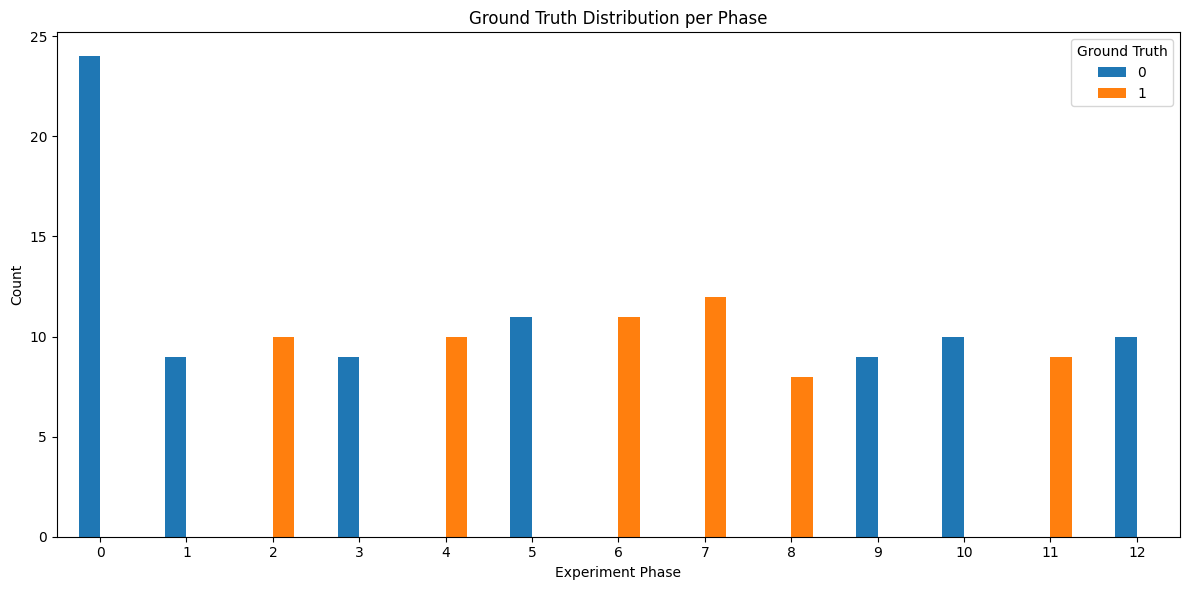


BASELINE CLASSIFICATION PER PHASE
Baseline Classification  0    1    2    255
Phase                                      
0                         24    0    0    0
1                          0    4    5    0
2                          3    4    3    0
3                          4    5    0    0
4                          4    6    0    0
5                          1    5    5    0
6                          5    6    0    0
7                          7    4    0    1
8                          7    0    1    0
9                          6    3    0    0
10                         6    4    0    0
11                         5    3    1    0
12                         7    3    0    0


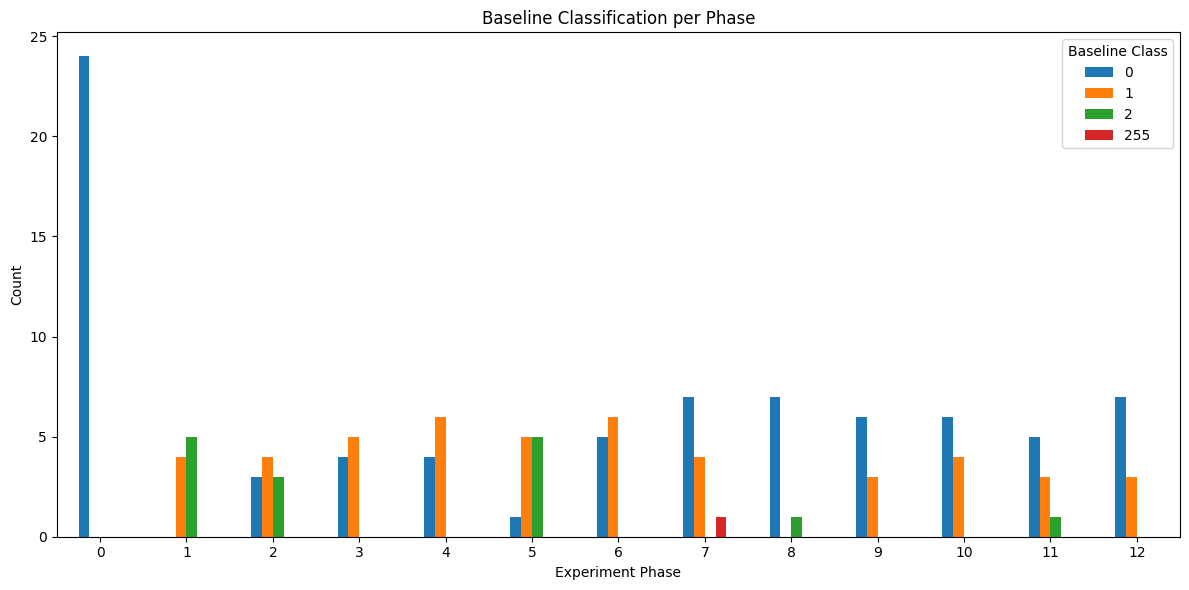

In [13]:
# ==========================================
# COMPARE baseline_classification vs ground_truth
# + ground_truth distribution per phase
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Compare baseline_classification
#    against ground_truth
# ------------------------------------------

comparison_df = pd.crosstab(
    df["ground_truth"],
    df["baseline_classification"],
    rownames=["Ground Truth"],
    colnames=["Baseline Classification"]
)

print("===================================================")
print("CONFUSION TABLE: baseline_classification vs ground_truth")
print("===================================================")
print(comparison_df)

# ------------------------------------------
# Accuracy
# ------------------------------------------

accuracy = (
    (df["baseline_classification"] == df["ground_truth"]).mean()
) * 100

print(f"\nOverall Accuracy: {accuracy:.2f}%")

# ------------------------------------------
# Misclassified samples
# ------------------------------------------

misclassified = df[
    df["baseline_classification"] != df["ground_truth"]
]

print("\n===================================================")
print("MISCLASSIFIED SAMPLES")
print("===================================================")
print(misclassified.head())

print(f"\nTotal Misclassified: {len(misclassified)}")

# ------------------------------------------
# 2. Compare ground_truth with phases
# ------------------------------------------

phase_truth = pd.crosstab(
    df["Experiment_Phase"],
    df["ground_truth"],
    rownames=["Phase"],
    colnames=["Ground Truth"]
)

print("\n===================================================")
print("GROUND TRUTH DISTRIBUTION PER PHASE")
print("===================================================")
print(phase_truth)

# ------------------------------------------
# Plot: ground truth per phase
# ------------------------------------------

phase_truth.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Ground Truth Distribution per Phase")
plt.xlabel("Experiment Phase")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.legend(title="Ground Truth")
plt.tight_layout()
plt.show()

# ------------------------------------------
# Optional:
# Compare baseline classification per phase
# ------------------------------------------

phase_baseline = pd.crosstab(
    df["Experiment_Phase"],
    df["baseline_classification"],
    rownames=["Phase"],
    colnames=["Baseline Classification"]
)

print("\n===================================================")
print("BASELINE CLASSIFICATION PER PHASE")
print("===================================================")
print(phase_baseline)

phase_baseline.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Classification per Phase")
plt.xlabel("Experiment Phase")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.legend(title="Baseline Class")
plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# FEATURES
# ==========================================

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

In [5]:
# ==========================================
# PHASE -> EXPECTED STATE
# ==========================================

stress_phases = [1,3,5,7,9,11]

def phase_to_expected(phase):

    if phase in stress_phases:
        return 1

    return 0

df["expected_state"] = df[
    "Experiment_Phase"
].apply(phase_to_expected)

In [6]:
# ==========================================
# SOM CLUSTER INTERPRETATION
# ==========================================

cluster_to_state = {
    0: 0,
    1: 1,
    2: 1
}

df["predicted_state"] = df[
    "baseline_classification"
].map(cluster_to_state)

In [7]:
# ==========================================
# SOM CLUSTER INTERPRETATION
# ==========================================

cluster_to_state = {
    0: 0,
    1: 1,
    2: 1
}

df["predicted_state"] = df[
    "baseline_classification"
].map(cluster_to_state)

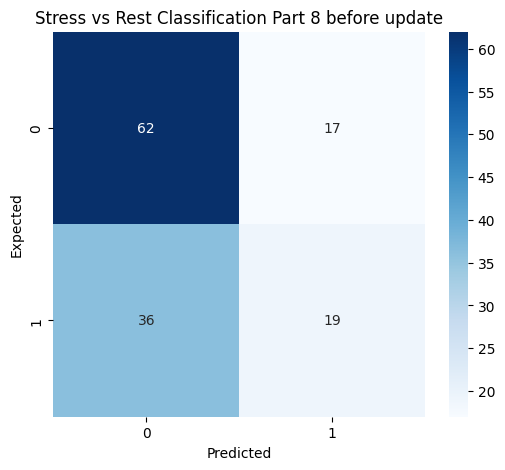

In [8]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    df["expected_state"],
    df["predicted_state"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Stress vs Rest Classification Part 8 before update")

plt.xlabel("Predicted")
plt.ylabel("Expected")

plt.show()

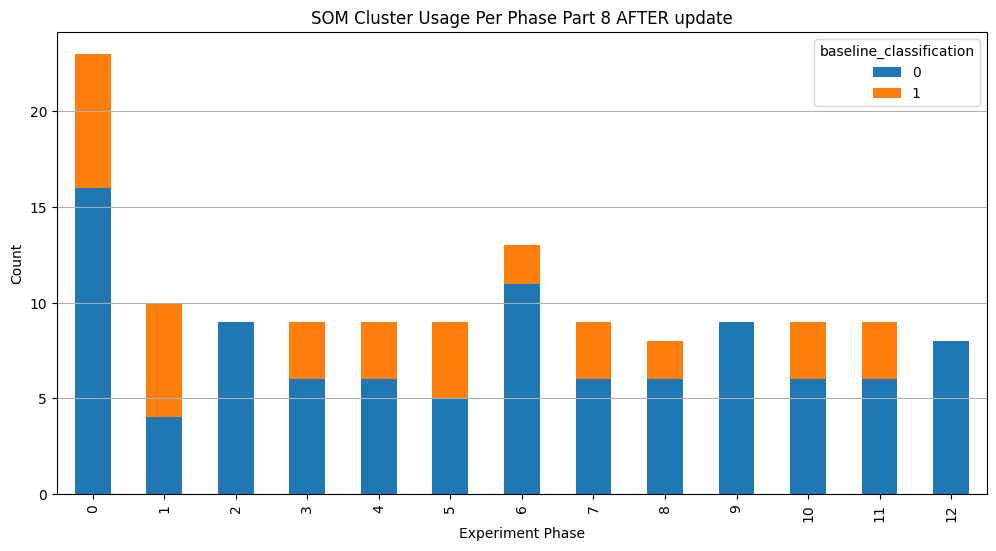

In [9]:
# ==========================================
# CLUSTER DISTRIBUTION PER PHASE
# ==========================================

phase_cluster = pd.crosstab(
    df["Experiment_Phase"],
    df["baseline_classification"]
)

phase_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("SOM Cluster Usage Per Phase Part 8 AFTER update")

plt.xlabel("Experiment Phase")
plt.ylabel("Count")

plt.grid(True, axis="y")

plt.show()

In [10]:
# =====================================================
# DETAILED PHASE ANALYSIS
# =====================================================

TARGET_PHASE = 11

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# =====================================================
# GET PHASE DATA
# =====================================================

phase_df = df[
    df["Experiment_Phase"] == TARGET_PHASE
].copy()

# =====================================================
# CLUSTER MEANS
# =====================================================

cluster_means = df.groupby(
    "baseline_classification"
)[feature_cols].mean()

# =====================================================
# ANALYZE EACH DATAPOINT
# =====================================================

results = []

for idx, row in phase_df.iterrows():

    sample = row[feature_cols].values

    distances = {}

    for cluster_id in cluster_means.index:

        cluster_vector = cluster_means.loc[
            cluster_id
        ].values

        dist = np.linalg.norm(
            sample - cluster_vector
        )

        distances[cluster_id] = dist

    closest_cluster = min(
        distances,
        key=distances.get
    )

    results.append({

        "classification":
            row["baseline_classification"],

        "closest_cluster":
            closest_cluster,

        "dist_cluster_0":
            distances[0],

        "dist_cluster_1":
            distances[1],

        "dist_cluster_2":
            distances[2],

        "HR":
            row["HR"],

        "RMSSD":
            row["RMSSD"],

        "SC_PH":
            row["SC_PH"],

        "SC_RR":
            row["SC_RR"]
    })

analysis_df = pd.DataFrame(results)

print(analysis_df)

TypeError: dtype 'str' does not support operation 'mean'

In [44]:
# ==========================================================
# FULL PHASE PHYSIOLOGICAL SIMILARITY ANALYSIS
# ==========================================================

import pandas as pd
import numpy as np

from scipy.spatial.distance import euclidean

# ==========================================================
# FEATURES
# ==========================================================

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================================
# DEFINE STRESS PHASES
# ==========================================================

stress_phases = [1,3,5,7,9,11]

# ==========================================================
# CLUSTER INTERPRETATION
# ==========================================================

cluster_labels = {
    0: "Recovery / Rest",
    1: "Moderate Stress",
    2: "High Stress"
}

# ==========================================================
# COMPUTE CLUSTER MEAN PHYSIOLOGY
# ==========================================================

cluster_means = df.groupby(
    "baseline_classification"
)[feature_cols].mean()

print("=" * 80)
print("SOM CLUSTER MEAN PHYSIOLOGY")
print("=" * 80)

print(cluster_means)

# ==========================================================
# ANALYZE EACH PHASE
# ==========================================================

all_results = []

for phase in sorted(df["Experiment_Phase"].unique()):

    print("\n")
    print("=" * 80)
    print(f"PHASE {phase} ANALYSIS")
    print("=" * 80)

    # ------------------------------------------------------
    # EXPECTED STATE
    # ------------------------------------------------------

    expected = (
        "STRESS"
        if phase in stress_phases
        else "REST"
    )

    print(f"\nExpected condition: {expected}")

    # ------------------------------------------------------
    # GET PHASE DATA
    # ------------------------------------------------------

    phase_df = df[
        df["Experiment_Phase"] == phase
    ].copy()

    # ------------------------------------------------------
    # PHASE MEAN PHYSIOLOGY
    # ------------------------------------------------------

    phase_mean = phase_df[
        feature_cols
    ].mean()

    print("\nMean physiological values:\n")

    print(
        phase_mean.round(3)
    )

    # ------------------------------------------------------
    # DISTANCE TO CLUSTERS
    # ------------------------------------------------------

    distances = {}

    for cluster_id in cluster_means.index:

        cluster_vector = cluster_means.loc[
            cluster_id
        ].values

        phase_vector = phase_mean.values

        dist = euclidean(
            phase_vector,
            cluster_vector
        )

        distances[cluster_id] = dist

    # ------------------------------------------------------
    # CLOSEST CLUSTER
    # ------------------------------------------------------

    closest_cluster = min(
        distances,
        key=distances.get
    )

    print("\nDistance to cluster physiology:\n")

    for cluster_id, dist in distances.items():

        print(
            f"Cluster {cluster_id} "
            f"({cluster_labels[cluster_id]}): "
            f"{dist:.3f}"
        )

    print("\nClosest physiological cluster:")

    print(
        f"Cluster {closest_cluster} "
        f"({cluster_labels[closest_cluster]})"
    )

    # ------------------------------------------------------
    # CLASSIFICATION DISTRIBUTION
    # ------------------------------------------------------

    counts = phase_df[
        "baseline_classification"
    ].value_counts().sort_index()

    print("\nCluster distribution:")

    for cluster_id in [0,1,2]:

        count = counts.get(cluster_id, 0)

        print(
            f"Cluster {cluster_id}: "
            f"{count} samples"
        )

    # ------------------------------------------------------
    # SCIENTIFIC INTERPRETATION
    # ------------------------------------------------------

    print("\nInterpretation:\n")

    if expected == "STRESS":

        if closest_cluster == 0:

            interpretation = (
                "Although this phase was designed "
                "as a stress condition, the mean "
                "physiological profile remained "
                "closest to the recovery-associated "
                "cluster. This suggests limited "
                "or short-lasting autonomic "
                "activation during the task."
            )

        elif closest_cluster == 1:

            interpretation = (
                "The physiological profile showed "
                "moderate sympathetic activation "
                "consistent with mild or transitional "
                "stress physiology."
            )

        else:

            interpretation = (
                "The physiological profile was "
                "closest to the high-stress cluster, "
                "indicating clear autonomic "
                "stress activation."
            )

    else:

        if closest_cluster == 0:

            interpretation = (
                "The physiological profile matched "
                "the recovery-associated cluster, "
                "consistent with resting conditions."
            )

        else:

            interpretation = (
                "Although this phase was intended "
                "as recovery/rest, the physiological "
                "profile retained partial similarity "
                "to stress-associated clusters."
            )

    print(interpretation)

    # ------------------------------------------------------
    # STORE RESULTS
    # ------------------------------------------------------

    all_results.append({

        "phase":
            phase,

        "expected":
            expected,

        "closest_cluster":
            closest_cluster,

        "cluster_label":
            cluster_labels[
                closest_cluster
            ],

        "dist_cluster_0":
            distances[0],

        "dist_cluster_1":
            distances[1],

        "dist_cluster_2":
            distances[2],

        "mean_HR":
            phase_mean["HR"],

        "mean_RMSSD":
            phase_mean["RMSSD"],

        "mean_SC_PH":
            phase_mean["SC_PH"],

        "mean_SC_RR":
            phase_mean["SC_RR"]
    })

# ==========================================================
# FINAL SUMMARY TABLE
# ==========================================================

summary_df = pd.DataFrame(all_results)

print("\n")
print("=" * 80)
print("FINAL PHASE SUMMARY")
print("=" * 80)

print(
    summary_df.round(3)
)

SOM CLUSTER MEAN PHYSIOLOGY
                                HR      RMSSD     SC_PH     SC_RR
baseline_classification                                          
0                        63.644553  53.084397  0.000635  0.012626


PHASE 0 ANALYSIS

Expected condition: REST

Mean physiological values:

HR       69.108
RMSSD    55.781
SC_PH     0.001
SC_RR     0.025
dtype: float64

Distance to cluster physiology:

Cluster 0 (Recovery / Rest): 6.093

Closest physiological cluster:
Cluster 0 (Recovery / Rest)

Cluster distribution:
Cluster 0: 23 samples
Cluster 1: 0 samples
Cluster 2: 0 samples

Interpretation:

The physiological profile matched the recovery-associated cluster, consistent with resting conditions.


KeyError: 1

In [56]:
# ==========================================================
# FULL PHASE SUMMARY
# USING STATIC SOM CLUSTER MEAN VALUES
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# FEATURES
# ==========================================================

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================================
# STATIC SOM CLUSTER MEANS
# FROM TRAINED SOM MODEL
# ==========================================================

cluster_means = pd.DataFrame({

    "HR": [
        75.013860,
        74.446526,
        88.800866
    ],

    "RMSSD": [
        55.587527,
        46.306015,
        34.648319
    ],

    "SC_PH": [
        0.691223,
        3.316771,
        1.386802
    ],

    "SC_RR": [
        0.063544,
        0.073333,
        0.134661
    ]

}, index=[0,1,2])

# ==========================================================
# CLUSTER LABELS
# ==========================================================

cluster_labels = {
    0: "Rest",
    1: "Active",
    2: "Stress"
}

# ==========================================================
# PRINT HEADER
# ==========================================================

print(
    f"{'PHASE':<8}"
    f"{'HR':<12}"
    f"{'RMSSD':<12}"
    f"{'SC_PH':<12}"
    f"{'SC_RR':<12}"
    f"{'DIST_C0':<12}"
    f"{'DIST_C1':<12}"
    f"{'DIST_C2':<12}"
    f"{'CLOSEST':<12}"
)

print("=" * 110)

# ==========================================================
# LOOP THROUGH PHASES
# ==========================================================

for phase in sorted(df["Experiment_Phase"].unique()):

    phase_df = df[
        df["Experiment_Phase"] == phase
    ]

    # ------------------------------------------------------
    # PHASE MEAN
    # ------------------------------------------------------

    phase_mean = phase_df[
        feature_cols
    ].mean()

    phase_vector = phase_mean.values

    # ------------------------------------------------------
    # DISTANCES
    # ------------------------------------------------------

    distances = {}

    for cluster_id in cluster_means.index:

        cluster_vector = cluster_means.loc[
            cluster_id
        ].values

        dist = np.linalg.norm(
            phase_vector -
            cluster_vector
        )

        distances[cluster_id] = dist

    # ------------------------------------------------------
    # CLOSEST CLUSTER
    # ------------------------------------------------------

    closest_cluster = min(
        distances,
        key=distances.get
    )

    # ------------------------------------------------------
    # PRINT
    # ------------------------------------------------------

    print(
        f"{phase:<8}"
        f"{phase_mean['HR']:<12.2f}"
        f"{phase_mean['RMSSD']:<12.2f}"
        f"{phase_mean['SC_PH']:<12.2f}"
        f"{phase_mean['SC_RR']:<12.4f}"
        f"{distances[0]:<12.3f}"
        f"{distances[1]:<12.3f}"
        f"{distances[2]:<12.3f}"
        f"{cluster_labels[closest_cluster]:<12}"
    )

PHASE   HR          RMSSD       SC_PH       SC_RR       DIST_C0     DIST_C1     DIST_C2     CLOSEST     
0       69.13       36.02       0.63        0.0029      20.432      11.885      19.737      Active      
1       67.25       31.87       1.19        0.0074      24.963      16.272      21.729      Active      
2       67.77       42.24       1.32        0.0367      15.203      8.072       22.361      Active      
3       66.74       31.63       1.35        0.0204      25.355      16.693      22.263      Active      
4       64.22       47.69       0.83        0.0074      13.376      10.615      27.831      Active      
5       67.54       33.95       2.03        0.0444      22.935      14.218      21.282      Active      
6       68.89       49.55       1.63        0.0383      8.653       6.656       24.875      Active      
7       67.02       38.36       1.51        0.0278      19.011      11.025      22.095      Active      
8       67.81       46.05       0.95        0.0117     

BASELINE PHYSIOLOGICAL PROFILE

HR
Mean : 69.127
Min  : 65.379
Max  : 72.459
Std  : 2.267

RMSSD
Mean : 36.023
Min  : 32.251
Max  : 39.706
Std  : 1.857

SC_PH
Mean : 0.633
Min  : 0.079
Max  : 1.713
Std  : 0.441

SC_RR
Mean : 0.003
Min  : 0.000
Max  : 0.067
Std  : 0.014


BASELINE DISTANCE TO SOM CLUSTERS

Cluster 0 (Rest)
Distance: 20.432

Cluster 1 (Active)
Distance: 11.885

Cluster 2 (Stress)
Distance: 19.737


CLOSEST BASELINE CLUSTER
Cluster 1 (Active)


BASELINE VS SOM CLUSTERS
                   HR   RMSSD  SC_PH  SC_RR
0              75.014  55.588  0.691  0.064
1              74.447  46.306  3.317  0.073
2              88.801  34.648  1.387  0.135
Baseline Mean  69.127  36.023  0.633  0.003


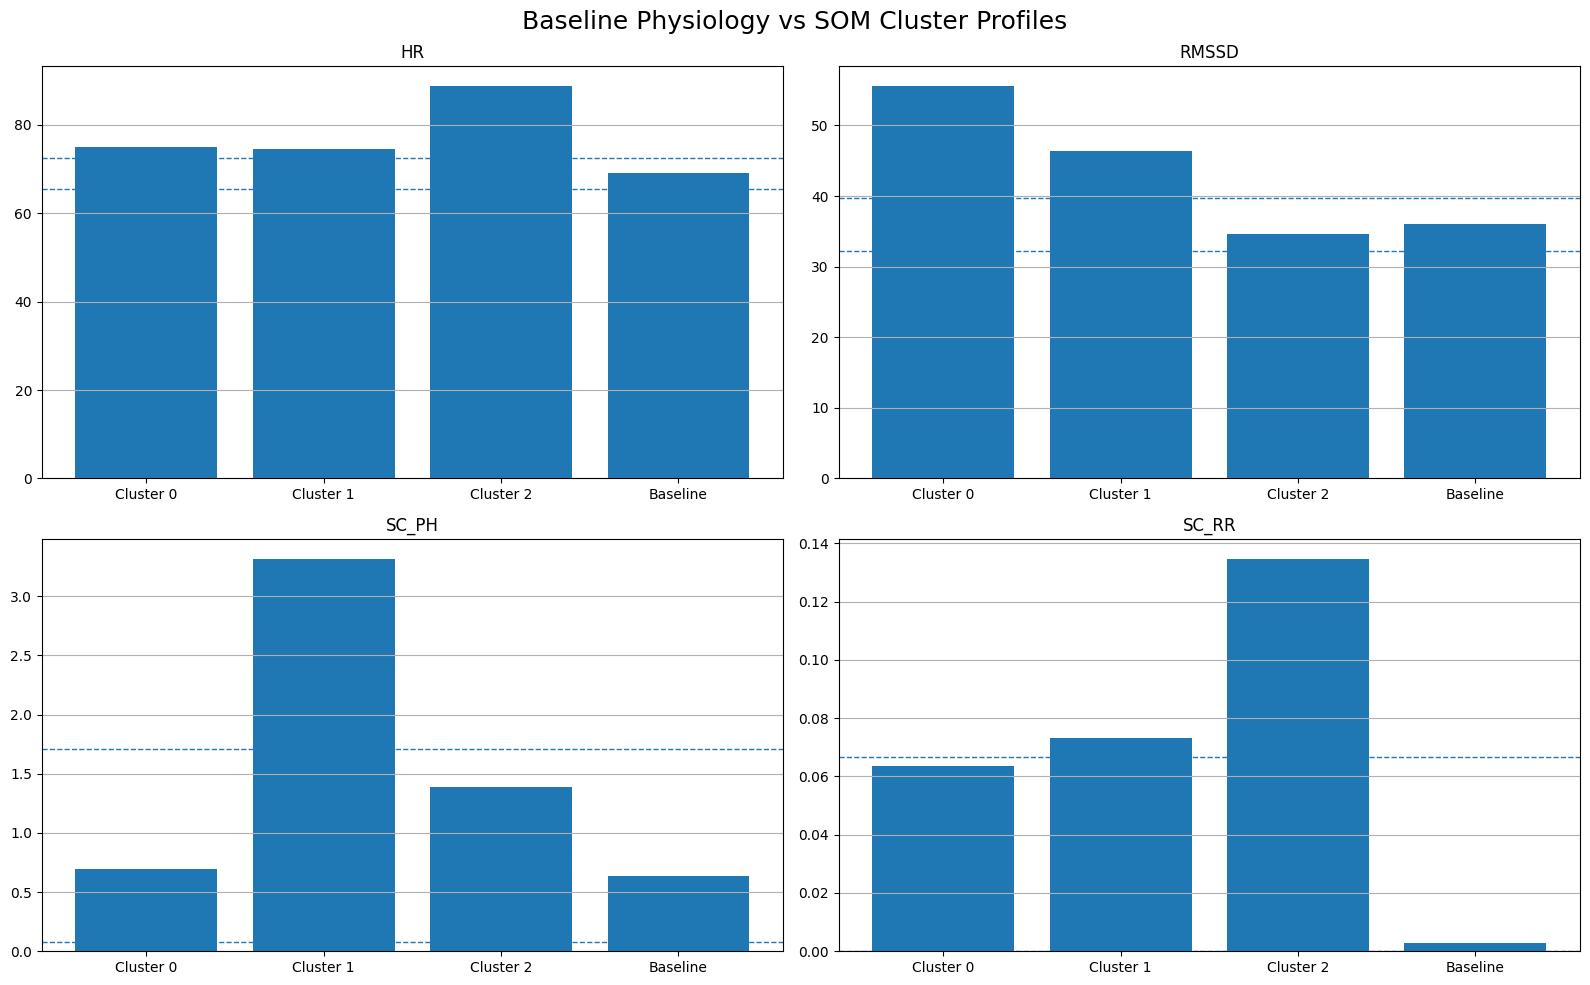



INTERPRETATION

The participant baseline physiology was physiologically closest to Cluster 1 (Active).

This indicates how the participant's normal resting physiology relates to the global SOM stress representation.


In [57]:
# ==========================================================
# BASELINE PHYSIOLOGICAL ANALYSIS
# Compare personal baseline vs SOM cluster means
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FEATURES
# ==========================================================

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================================
# STATIC SOM CLUSTER MEANS
# ==========================================================

cluster_means = pd.DataFrame({

    "HR": [
        75.013860,
        74.446526,
        88.800866
    ],

    "RMSSD": [
        55.587527,
        46.306015,
        34.648319
    ],

    "SC_PH": [
        0.691223,
        3.316771,
        1.386802
    ],

    "SC_RR": [
        0.063544,
        0.073333,
        0.134661
    ]

}, index=[0,1,2])

cluster_labels = {
    0: "Rest",
    1: "Active",
    2: "Stress"
}

# ==========================================================
# BASELINE DATA
# PHASE 0 = BASELINE
# ==========================================================

baseline_df = df[
    df["Experiment_Phase"] == 0
]

# ==========================================================
# BASELINE STATISTICS
# ==========================================================

baseline_mean = baseline_df[
    feature_cols
].mean()

baseline_min = baseline_df[
    feature_cols
].min()

baseline_max = baseline_df[
    feature_cols
].max()

baseline_std = baseline_df[
    feature_cols
].std()

# ==========================================================
# PRINT RESULTS
# ==========================================================

print("=" * 80)
print("BASELINE PHYSIOLOGICAL PROFILE")
print("=" * 80)

for feature in feature_cols:

    print(
        f"\n{feature}"
    )

    print(
        f"Mean : {baseline_mean[feature]:.3f}"
    )

    print(
        f"Min  : {baseline_min[feature]:.3f}"
    )

    print(
        f"Max  : {baseline_max[feature]:.3f}"
    )

    print(
        f"Std  : {baseline_std[feature]:.3f}"
    )

# ==========================================================
# DISTANCE TO SOM CLUSTERS
# ==========================================================

print("\n")
print("=" * 80)
print("BASELINE DISTANCE TO SOM CLUSTERS")
print("=" * 80)

baseline_vector = baseline_mean.values

distances = {}

for cluster_id in cluster_means.index:

    cluster_vector = cluster_means.loc[
        cluster_id
    ].values

    dist = np.linalg.norm(
        baseline_vector -
        cluster_vector
    )

    distances[cluster_id] = dist

    print(
        f"\nCluster {cluster_id} "
        f"({cluster_labels[cluster_id]})"
    )

    print(
        f"Distance: {dist:.3f}"
    )

closest_cluster = min(
    distances,
    key=distances.get
)

print("\n")
print("=" * 80)
print("CLOSEST BASELINE CLUSTER")
print("=" * 80)

print(
    f"Cluster {closest_cluster} "
    f"({cluster_labels[closest_cluster]})"
)

# ==========================================================
# CREATE COMPARISON TABLE
# ==========================================================

comparison_df = cluster_means.copy()

comparison_df.loc[
    "Baseline Mean"
] = baseline_mean

print("\n")
print("=" * 80)
print("BASELINE VS SOM CLUSTERS")
print("=" * 80)

print(
    comparison_df.round(3)
)

# ==========================================================
# VISUALIZATION
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

for feature, ax in zip(feature_cols, axes.flat):

    values = [
        cluster_means.loc[0, feature],
        cluster_means.loc[1, feature],
        cluster_means.loc[2, feature],
        baseline_mean[feature]
    ]

    labels = [
        "Cluster 0",
        "Cluster 1",
        "Cluster 2",
        "Baseline"
    ]

    bars = ax.bar(
        labels,
        values
    )

    # highlight baseline
    bars[-1].set_linewidth(3)

    # baseline min/max
    ax.axhline(
        baseline_min[feature],
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        baseline_max[feature],
        linestyle="--",
        linewidth=1
    )

    ax.set_title(feature)

    ax.grid(True, axis="y")

plt.suptitle(
    "Baseline Physiology vs SOM Cluster Profiles",
    fontsize=18
)

plt.tight_layout()

plt.show()

# ==========================================================
# OPTIONAL TEXT INTERPRETATION
# ==========================================================

print("\n")
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(
    f"\nThe participant baseline physiology "
    f"was physiologically closest to "
    f"Cluster {closest_cluster} "
    f"({cluster_labels[closest_cluster]})."
)

print(
    "\nThis indicates how the participant's "
    "normal resting physiology relates "
    "to the global SOM stress representation."
)

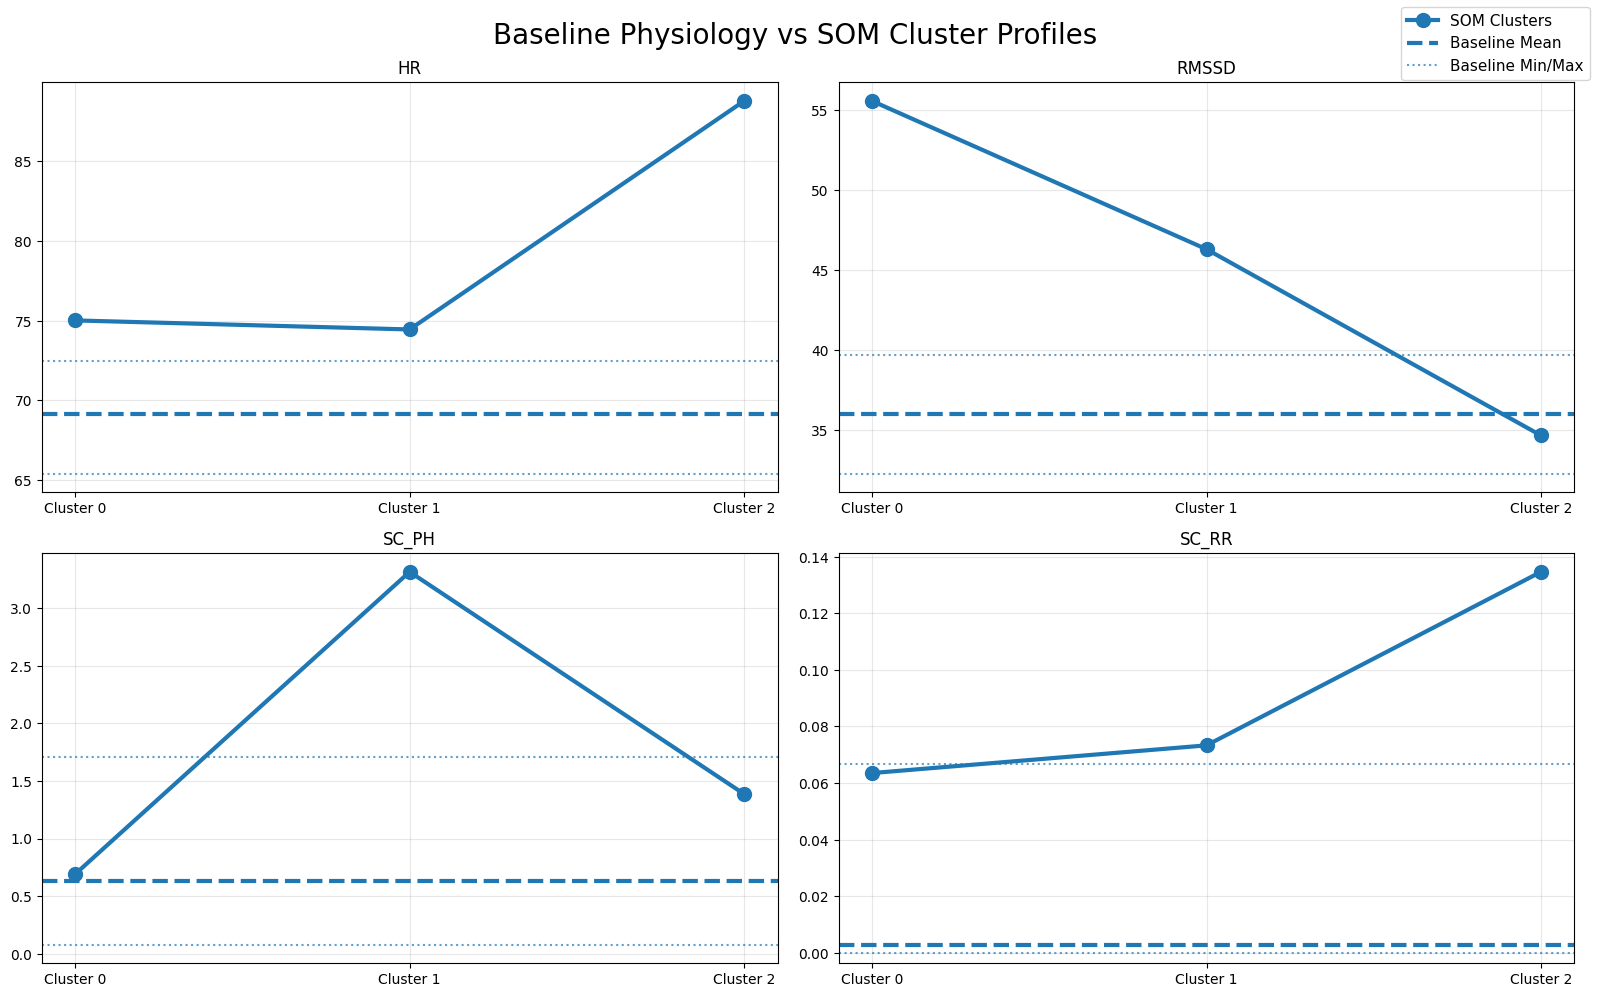

In [58]:
# ==========================================================
# BASELINE vs SOM CLUSTERS
# LINE PLOT VERSION
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# SOM CLUSTER MEANS
# ==========================================================

cluster_means = pd.DataFrame({

    "HR": [
        75.013860,
        74.446526,
        88.800866
    ],

    "RMSSD": [
        55.587527,
        46.306015,
        34.648319
    ],

    "SC_PH": [
        0.691223,
        3.316771,
        1.386802
    ],

    "SC_RR": [
        0.063544,
        0.073333,
        0.134661
    ]

}, index=[
    "Cluster 0",
    "Cluster 1",
    "Cluster 2"
])

# ==========================================================
# BASELINE DATA
# ==========================================================

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

baseline_df = df[
    df["Experiment_Phase"] == 0
]

baseline_mean = baseline_df[
    feature_cols
].mean()

# ==========================================================
# CREATE PLOT
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

for feature, ax in zip(feature_cols, axes.flat):

    # cluster values
    y = [
        cluster_means.loc["Cluster 0", feature],
        cluster_means.loc["Cluster 1", feature],
        cluster_means.loc["Cluster 2", feature]
    ]

    x = [0,1,2]

    # SOM cluster line
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=3,
        markersize=10,
        label="SOM Clusters"
    )

    # Baseline line
    ax.axhline(
        baseline_mean[feature],
        linestyle="--",
        linewidth=3,
        label="Baseline Mean"
    )

    # baseline min/max
    ax.axhline(
        baseline_df[feature].min(),
        linestyle=":",
        linewidth=1.5,
        alpha=0.7,
        label="Baseline Min/Max"
    )

    ax.axhline(
        baseline_df[feature].max(),
        linestyle=":",
        linewidth=1.5,
        alpha=0.7
    )

    # labels
    ax.set_xticks(x)

    ax.set_xticklabels([
        "Cluster 0",
        "Cluster 1",
        "Cluster 2"
    ])

    ax.set_title(feature)

    ax.grid(True, alpha=0.3)

# ==========================================================
# TITLE
# ==========================================================

plt.suptitle(
    "Baseline Physiology vs SOM Cluster Profiles",
    fontsize=20
)

# ==========================================================
# CLEAN LEGEND
# ==========================================================

handles, labels = axes[0,0].get_legend_handles_labels()

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    fontsize=11
)

plt.tight_layout()

plt.show()

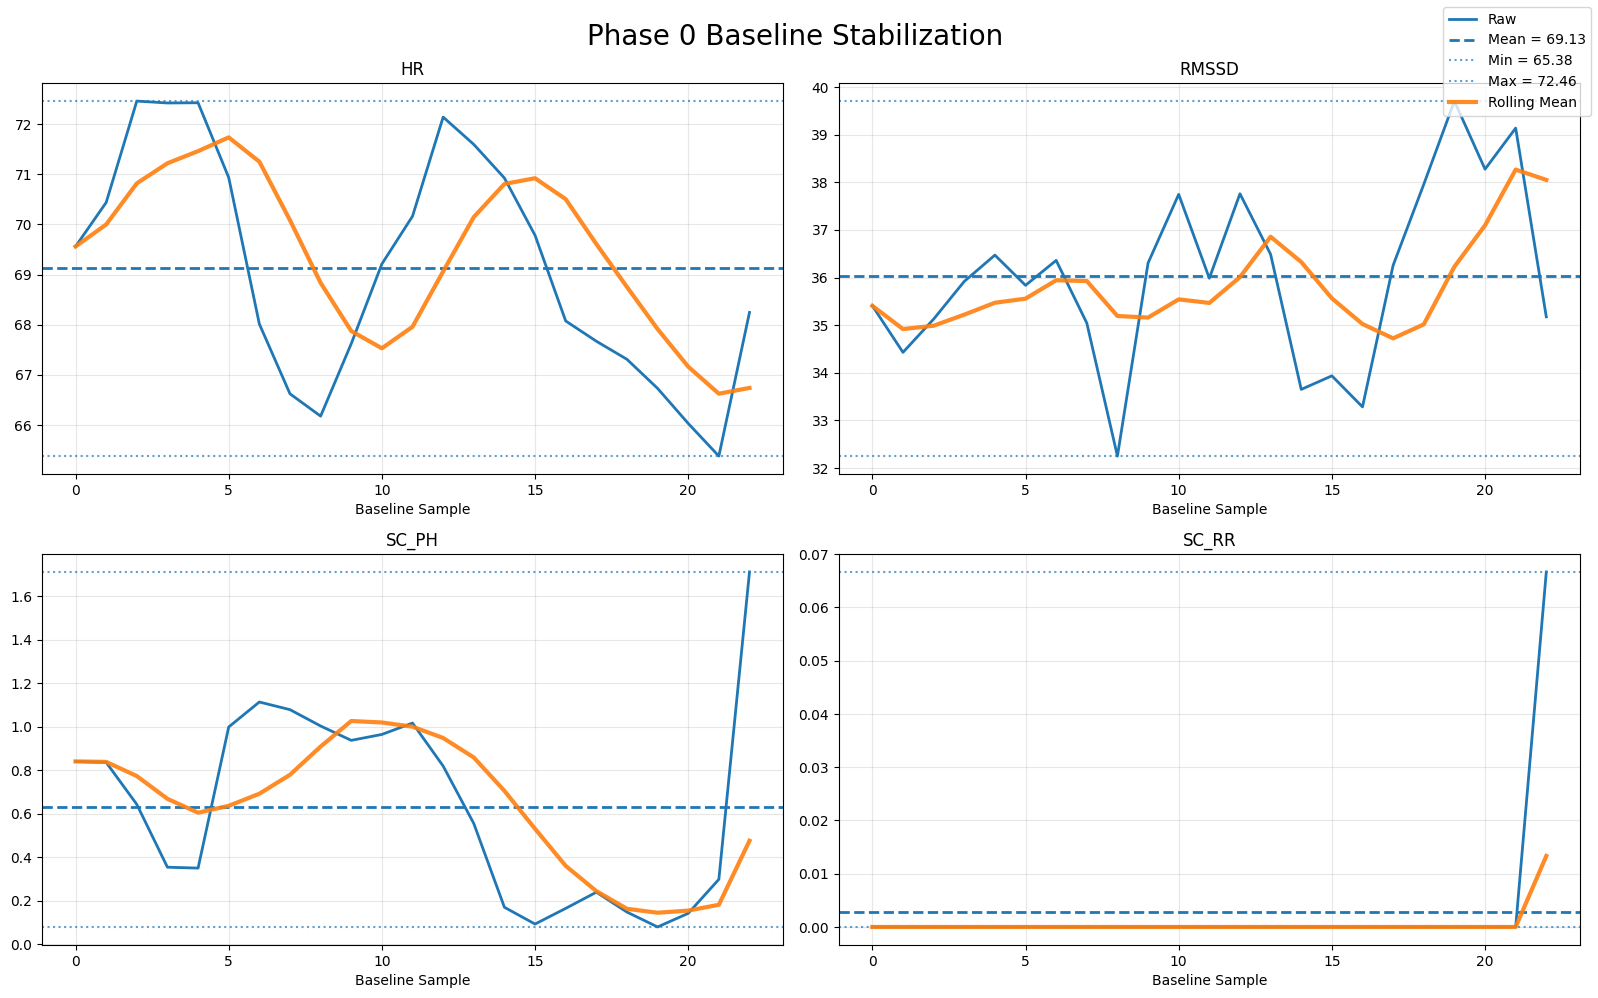

BASELINE STABILITY SUMMARY

HR
Mean : 69.127
Std  : 2.267
Min  : 65.379
Max  : 72.459
Range: 7.079

RMSSD
Mean : 36.023
Std  : 1.857
Min  : 32.251
Max  : 39.706
Range: 7.455

SC_PH
Mean : 0.633
Std  : 0.441
Min  : 0.079
Max  : 1.713
Range: 1.634

SC_RR
Mean : 0.003
Std  : 0.014
Min  : 0.000
Max  : 0.067
Range: 0.067


In [59]:
# ==========================================================
# BASELINE STABILIZATION ANALYSIS
# PHASE 0 ONLY
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# FEATURES
# ==========================================================

feature_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

# ==========================================================
# BASELINE DATA (PHASE 0)
# ==========================================================

baseline_df = df[
    df["Experiment_Phase"] == 0
].reset_index(drop=True)

# ==========================================================
# TIME AXIS
# ==========================================================

x = np.arange(len(baseline_df))

# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

for feature, ax in zip(feature_cols, axes.flat):

    y = baseline_df[feature]

    # raw signal
    ax.plot(
        x,
        y,
        linewidth=2,
        label="Raw"
    )

    # mean
    ax.axhline(
        y.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {y.mean():.2f}"
    )

    # min/max
    ax.axhline(
        y.min(),
        linestyle=":",
        linewidth=1.5,
        alpha=0.7,
        label=f"Min = {y.min():.2f}"
    )

    ax.axhline(
        y.max(),
        linestyle=":",
        linewidth=1.5,
        alpha=0.7,
        label=f"Max = {y.max():.2f}"
    )

    # rolling mean
    rolling = y.rolling(
        window=5,
        min_periods=1
    ).mean()

    ax.plot(
        x,
        rolling,
        linewidth=3,
        alpha=0.9,
        label="Rolling Mean"
    )

    ax.set_title(feature)

    ax.set_xlabel("Baseline Sample")

    ax.grid(True, alpha=0.3)

# ==========================================================
# TITLE
# ==========================================================

plt.suptitle(
    "Phase 0 Baseline Stabilization",
    fontsize=20
)

# ==========================================================
# LEGEND
# ==========================================================

handles, labels = axes[0,0].get_legend_handles_labels()

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    fontsize=10
)

plt.tight_layout()

plt.show()

# ==========================================================
# PRINT SUMMARY
# ==========================================================

print("=" * 70)
print("BASELINE STABILITY SUMMARY")
print("=" * 70)

for feature in feature_cols:

    values = baseline_df[feature]

    print(f"\n{feature}")

    print(f"Mean : {values.mean():.3f}")

    print(f"Std  : {values.std():.3f}")

    print(f"Min  : {values.min():.3f}")

    print(f"Max  : {values.max():.3f}")

    print(
        f"Range: "
        f"{(values.max()-values.min()):.3f}"
    )